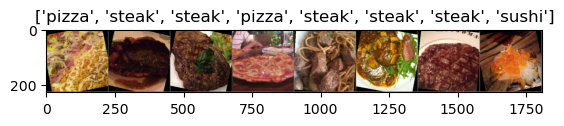

Epoch 1/20, Train Loss: 1.1950, Val Loss: 1.0928, Train Acc: 0.2876, Val Acc: 0.3867
Epoch 2/20, Train Loss: 0.9949, Val Loss: 0.8229, Train Acc: 0.5177, Val Acc: 0.7200
Epoch 3/20, Train Loss: 0.9110, Val Loss: 0.7744, Train Acc: 0.5664, Val Acc: 0.6400
Epoch 4/20, Train Loss: 0.6819, Val Loss: 0.6372, Train Acc: 0.7920, Val Acc: 0.7867
Epoch 5/20, Train Loss: 0.5884, Val Loss: 0.5484, Train Acc: 0.8142, Val Acc: 0.8267
Epoch 6/20, Train Loss: 0.5437, Val Loss: 0.5272, Train Acc: 0.8451, Val Acc: 0.9067
Epoch 7/20, Train Loss: 0.5224, Val Loss: 0.5180, Train Acc: 0.8717, Val Acc: 0.8933
Epoch 8/20, Train Loss: 0.5202, Val Loss: 0.5003, Train Acc: 0.8496, Val Acc: 0.8933
Epoch 9/20, Train Loss: 0.4991, Val Loss: 0.4974, Train Acc: 0.8894, Val Acc: 0.8933
Epoch 10/20, Train Loss: 0.5207, Val Loss: 0.4995, Train Acc: 0.8451, Val Acc: 0.9067
Epoch 11/20, Train Loss: 0.5026, Val Loss: 0.5052, Train Acc: 0.8673, Val Acc: 0.9067
Epoch 12/20, Train Loss: 0.4971, Val Loss: 0.4976, Train Acc: 0

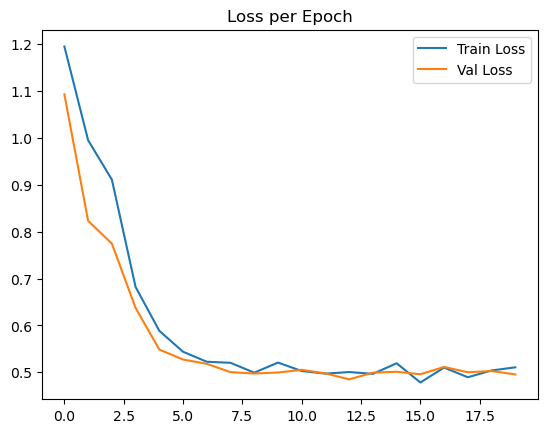

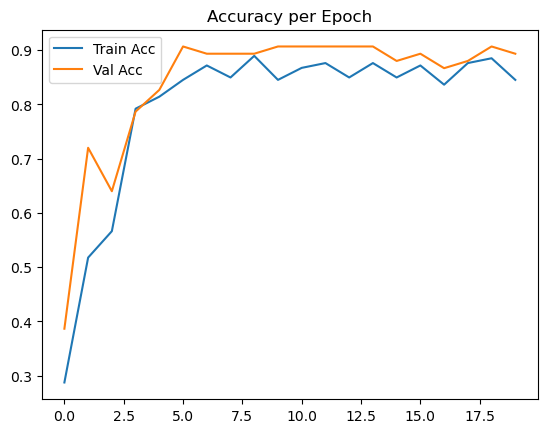

Test Accuracy: 0.8933333333333333
Precision: 0.8933333333333333
Recall: 0.8933333333333333
F1 Score: 0.8930811265237495
Classification Report:
               precision    recall  f1-score   support

       pizza       0.88      0.88      0.88        25
       steak       0.90      0.95      0.92        19
       sushi       0.90      0.87      0.89        31

    accuracy                           0.89        75
   macro avg       0.89      0.90      0.90        75
weighted avg       0.89      0.89      0.89        75



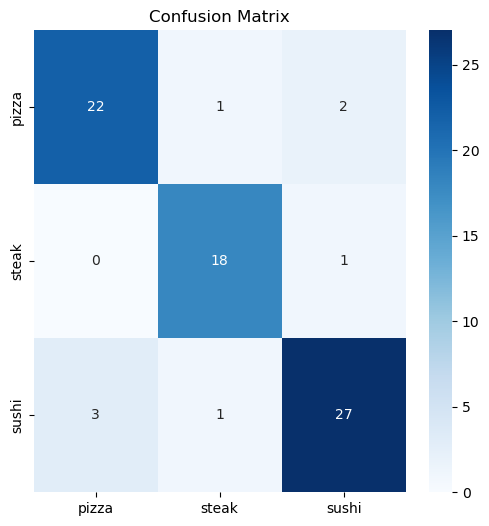

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, models, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import shutil

for root in [train_dir, test_dir]:
    checkpoints_path = os.path.join(root, '.ipynb_checkpoints')
    if os.path.exists(checkpoints_path):
        shutil.rmtree(checkpoints_path)

# Paths
train_dir = 'Assignment5_Files/Food/train'
test_dir = 'Assignment5_Files/Food/test'

# Parameters
batch_size = 32
num_classes = 3
num_epochs = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


def is_valid_file(path):
    return path.lower().endswith(('.jpg'))

# Datasets and loaders
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms, is_valid_file=is_valid_file)
val_dataset = datasets.ImageFolder(test_dir, transform=val_transforms, is_valid_file=is_valid_file)


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

class_names = train_dataset.classes

# Display a batch of training images
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    inp = imagenet_std * inp + imagenet_mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

inputs, classes = next(iter(train_loader))
out = utils.make_grid(inputs[:8])
imshow(out, title=[class_names[x] for x in classes[:8]])
plt.show()

# Load pre-trained ResNet-18
model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False

# Replace final FC layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(device)

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.fc.parameters(), lr=0.001, momentum=0.9)
scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# Training loop
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_acc = 0
best_model_wts = None

for epoch in range(num_epochs):
    model.train()
    running_loss, running_corrects = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc.item())

    # Validation
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
    val_epoch_loss = val_loss / len(val_dataset)
    val_epoch_acc = val_corrects.double() / len(val_dataset)
    val_losses.append(val_epoch_loss)
    val_accs.append(val_epoch_acc.item())

    if val_epoch_acc > best_acc:
        best_acc = val_epoch_acc
        best_model_wts = model.state_dict()

    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Acc: {val_epoch_acc:.4f}")

# Save best model
torch.save(best_model_wts, 'best_resnet18.pth')

# Plot training curves
plt.figure()
plt.plot(range(num_epochs), train_losses, label='Train Loss')
plt.plot(range(num_epochs), val_losses, label='Val Loss')
plt.legend()
plt.title('Loss per Epoch')
plt.show()

plt.figure()
plt.plot(range(num_epochs), train_accs, label='Train Acc')
plt.plot(range(num_epochs), val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy per Epoch')
plt.show()

# Evaluation on test set
model.load_state_dict(best_model_wts)
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
cm = confusion_matrix(y_true, y_pred)

print("Test Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix plot
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.show()